# Import Libraries

In [83]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.tree import plot_tree

import matplotlib.pyplot as plt

# Load Data Set

In [84]:
df = pd.read_csv("Clean_Titanic_Data.csv")

# Seprate Featuers and Target Variables

In [85]:
X = df[
    [
        "Pclass",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "FamilySize",
        "is_alone",
        "TicketGroupSize",
        "FarePerPerson",
        "Sex",
        "Embarked_C",
        "Embarked_Q",
        "Embarked_S",
        "Deck_A",
        "Deck_B",
        "Deck_C",
        "Deck_D",
        "Deck_E",
        "Deck_F",
        "Deck_G"
    ]
]



y = df["Survived"]


# Split train and Test Data

In [86]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2    
)

# Creat Models

## 1. Logestic Regression

In [87]:
model = LogisticRegression(max_iter=100)

# Train model
model.fit(X_train, y_train)


c:\Users\PC\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [88]:
y_pred = model.predict(X_test)


## 2. Tree Decision

In [89]:
model_tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

In [90]:
model_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [91]:
y_pred_tree = model_tree.predict(X_test)

# Comparison

1. Accuracy

In [92]:
logistic_accuracy = accuracy_score(y_test, y_pred)
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Logistic Regression Accuracy: ", logistic_accuracy)
print("Decision Tree Accuracy:       ", tree_accuracy)

Logistic Regression Accuracy:  0.7653631284916201
Decision Tree Accuracy:        0.7988826815642458


2. Confusion Matrix

In [93]:
print("Logistic Regression:")
print(confusion_matrix(y_test, y_pred))

print("\nDecision Tree:")
print(confusion_matrix(y_test, y_pred_tree))

Logistic Regression:
[[91 22]
 [20 46]]

Decision Tree:
[[104   9]
 [ 27  39]]


3. Classification Report

In [94]:
print("                ===== Logistic Regression =====")
print(classification_report(y_test, y_pred))

print("\n***************************************************************\n")

print("              ===== Decision Tree =====")
print(classification_report(y_test, y_pred_tree))

                ===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.82      0.81      0.81       113
           1       0.68      0.70      0.69        66

    accuracy                           0.77       179
   macro avg       0.75      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179


***************************************************************

              ===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       113
           1       0.81      0.59      0.68        66

    accuracy                           0.80       179
   macro avg       0.80      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



## Comaprison Visuals

1. Accuracy comparison

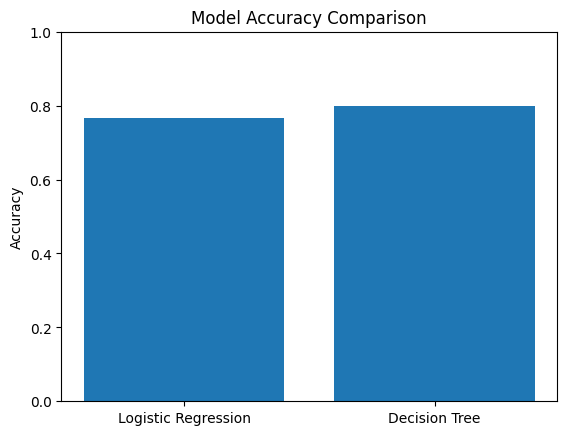

In [95]:
models = ["Logistic Regression", "Decision Tree"]
accuracies = [logistic_accuracy, tree_accuracy]

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 1)

plt.show()

2. Precision, Recall & F1 comparison

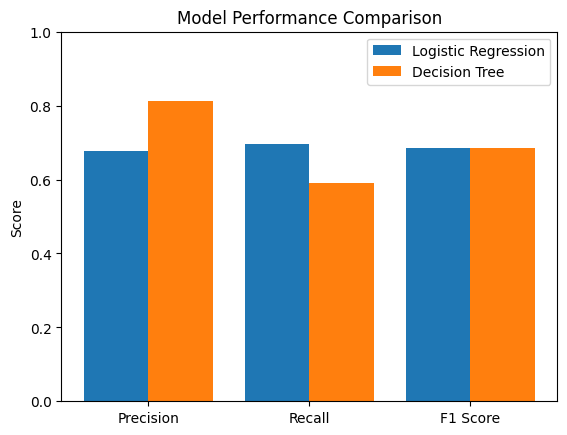

In [96]:
metrics = ["Precision", "Recall", "F1 Score"]

logistic_scores = [
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred)
]

tree_scores = [
    precision_score(y_test, y_pred_tree),
    recall_score(y_test, y_pred_tree),
    f1_score(y_test, y_pred_tree)
]

x = range(len(metrics))

plt.bar([i - 0.2 for i in x], logistic_scores, width=0.4, label="Logistic Regression")
plt.bar([i + 0.2 for i in x], tree_scores, width=0.4, label="Decision Tree")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.ylim(0, 1)
plt.legend()

plt.show()

3. Decession Tree

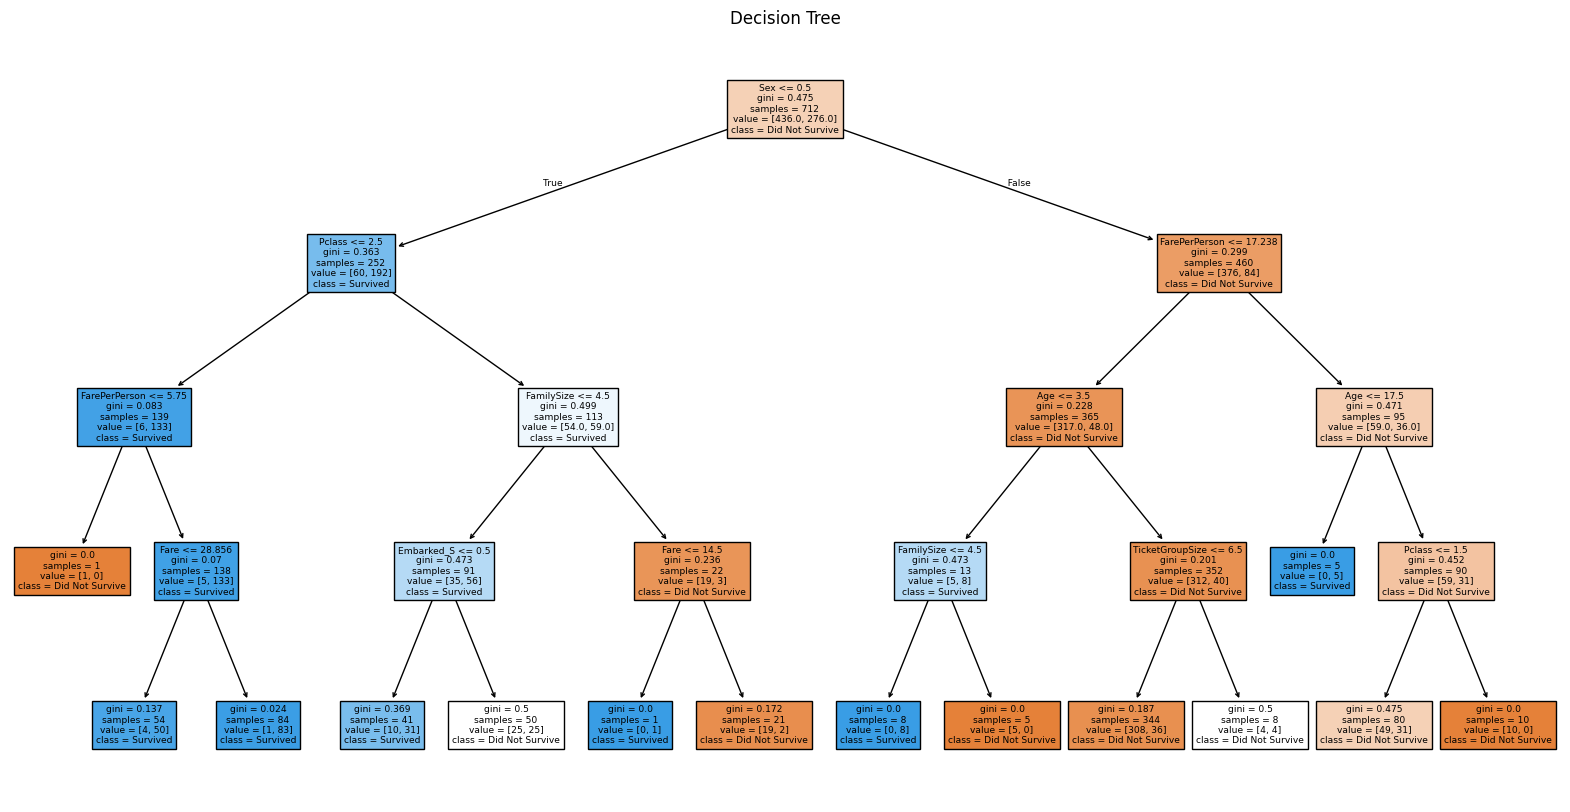

In [97]:
plt.figure(figsize=(20, 10))

plot_tree(
    model_tree,
    feature_names=X.columns,
    class_names=["Did Not Survive", "Survived"],
    filled=True
)

plt.title("Decision Tree")
plt.show()

# Conclusion
- Both Logistic Regression and Decision Tree were used to predict passenger survival.
- Logistic Regression is a simple and interpretable model that works well for binary classification.
- Decision Tree can capture more complex relationships between features and survival.
- The models were compared using Accuracy, Precision, Recall, and F1-score.
- overall **Logistic Regression Model** performed better.